In [8]:
import os
import json

# 1. Đọc file JSON để lấy quyền truy cập
with open('kaggle.json', 'r') as f:
    config = json.load(f)

os.environ['KAGGLE_USERNAME'] = config['username']
os.environ['KAGGLE_KEY'] = config['key']

# 2. Thiết lập thư mục đích
current_dir = os.getcwd()
print(f"--- ĐANG TẢI FRUITS-360-YOLO VỀ: {current_dir} ---")

# 3. Sử dụng lệnh hệ thống để tải trực tiếp (Cách này cực kỳ ổn định)
# Lệnh này sẽ tự động hiện thanh tiến trình % ngay dưới ô code
try:
    # Tải file zip về
    os.system("kaggle datasets download -d miguelcruz67/fruits-360-yolo")
    
    print("\n--- ĐANG GIẢI NÉN DỮ LIỆU ---")
    import zipfile
    with zipfile.ZipFile("fruits-360-yolo.zip", 'r') as zip_ref:
        zip_ref.extractall("fruits-360-yolo-data")
        
    print("\n" + "="*50)
    print("🔥 THÀNH CÔNG RỰC RỠ!")
    print(f"Dữ liệu đã nằm trong folder: fruits-360-data")
    print("="*50)
    
    # Xóa file zip cho nhẹ máy sau khi giải nén
    if os.path.exists("fruits-360-yolo.zip"):
        os.remove("fruits-360-yolo.zip")
        
except Exception as e:
    print(f"\n❌ Lỗi : {e}")

--- ĐANG TẢI FRUITS-360-YOLO VỀ: d:\Fruit_detection ---

--- ĐANG GIẢI NÉN DỮ LIỆU ---

🔥 THÀNH CÔNG RỰC RỠ!
Dữ liệu đã nằm trong folder: fruits-360-data


In [2]:
from ultralytics import YOLO
import torch

# 1. Kiểm tra xem có GPU (Card đồ họa) không
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"--- ĐANG CHẠY TRÊN: {device} ---")

# 2. Khởi tạo model YOLOv8 (Sẽ tự động tải file .pt về nếu chưa có)
model = YOLO("yolov8n.pt") 

# 3. Bắt đầu huấn luyện
model.train(
    data="fruits-360-yolo-data/fruits-360-yolo/data.yaml", # Đường dẫn tới file yaml bạn vừa sửa
    epochs=20,           # Chạy thử 20 lượt trước để xem độ chính xác
    imgsz=640,           # Kích thước ảnh chuẩn YOLO
    batch=16,            # Số lượng ảnh mỗi lần nạp (giảm xuống 8 nếu bị báo lỗi Out of Memory)
    device=device,       # Sử dụng GPU nếu có
    project="Fruit_Project", 
    name="yolo_fruits_v1"
)

--- ĐANG CHẠY TRÊN: 0 ---
Ultralytics 8.4.42  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=fruits-360-yolo-data/fruits-360-yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_fruits_v1-2, nbs=64, nms=False, opset=None, op

KeyboardInterrupt: 

In [3]:
from ultralytics import YOLO

# 1. Trỏ thẳng đến file 'last.pt' trong thư mục đang train dở
# Dựa trên ảnh của bạn, đường dẫn sẽ tương tự như sau:
checkpoint_path = "D:/Fruit_detection/runs/detect/Fruit_Project/yolo_fruits_v1-2/weights/last.pt"

# 2. Load model từ checkpoint
model = YOLO(checkpoint_path)

# 3. Tiếp tục huấn luyện (Chỉ cần thêm tham số resume=True)
model.train(resume=True, cache=True, workers=4,plots=True)

Ultralytics 8.4.42  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=fruits-360-yolo-data\fruits-360-yolo\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=D:\Fruit_detection\runs\detect\Fruit_Project\yolo_fruits_v1-2\weights\last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_fruits

KeyboardInterrupt: 

CODE TRAIN V2

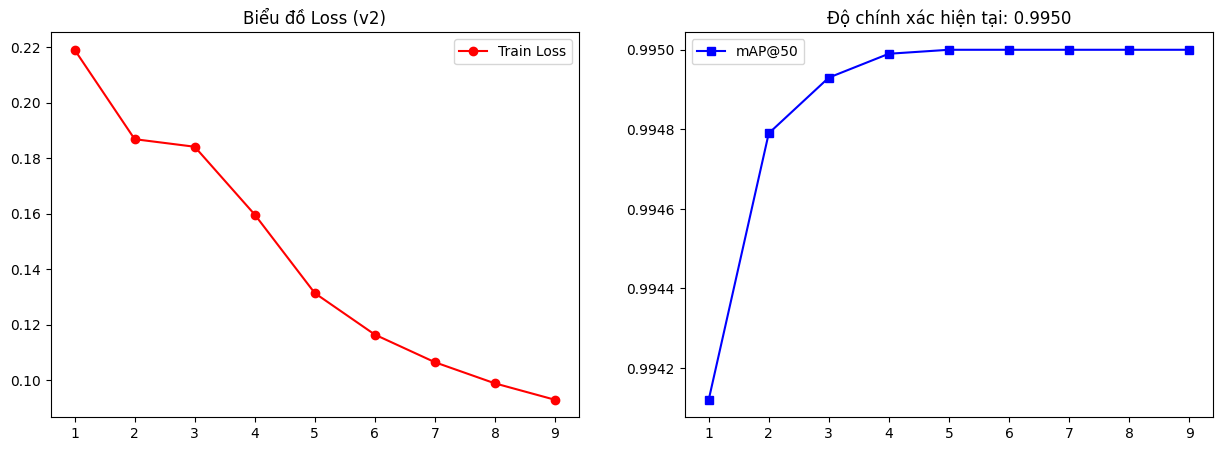

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
from IPython.display import clear_output

csv_path = r"D:\Fruit_detection\runs\detect\Fruit_Project\yolo_fruits_v1-2\results.csv"

while True:
    if os.path.exists(csv_path):
        try:
            df = pd.read_csv(csv_path)
            df.columns = [c.strip() for c in df.columns]
            if len(df) > 0:
                clear_output(wait=True)
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
                
                # Vẽ Loss
                ax1.plot(df['epoch'], df['train/box_loss'], 'r-o', label='Train Loss')
                ax1.set_title("Biểu đồ Loss (v2)")
                ax1.legend()
                
                # Vẽ mAP50
                ax2.plot(df['epoch'], df['metrics/mAP50(B)'], 'b-s', label='mAP@50')
                ax2.set_title(f"Độ chính xác hiện tại: {df['metrics/mAP50(B)'].iloc[-1]:.4f}")
                ax2.legend()
                
                plt.show()
        except:
            pass
    time.sleep(30)

In [ ]:
from ultralytics import YOLO
import cv2
import os

# 1. Load model anh vừa train xong
# Thường nằm trong: runs/detect/train/weights/best.pt
model = YOLO(r'D:\Fruit_detection\runs\detect\Fruit_Project\yolo_fruits_v1-2\weights\best.pt')

# 2. Đường dẫn đến tấm ảnh anh muốn test
img_path = 'D:\Fruit_detection\download.jpg'

# 3. Chạy nhận diện
# device=0 để dùng card GTX 1650
results = model.predict(source=img_path, conf=0.5, device=0)

# 4. Hiển thị và lưu kết quả
for r in results:
    # Vẽ box và label lên ảnh
    res_plotted = r.plot()
    
    # Hiển thị lên màn hình
    cv2.imshow("Ket qua nhan dien trai cay", res_plotted)
    
    # Nhấn phím bất kỳ để đóng cửa sổ ảnh
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    
    # Lưu ảnh kết quả ra thư mục hiện tại để anh xem lại
    r.save(filename='result_test.jpg')
    print("Anh da duoc luu tai: result_test.jpg")


image 1/1 d:\Fruit_detection\download.jpg: 352x640 1 Cabbage, 64.3ms
Speed: 3.2ms preprocess, 64.3ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)
